In [1]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 52.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import cv2
import math
import time
import types
import shutil
import random
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import vit_b_16, ViT_B_16_Weights

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
class CFG:
    KAGGLE_INPUT_ROOT = Path("/kaggle/input/datasets/quan0207/indoor-scene/indoorCVPR_09")
    SPLIT_ROOT = Path("/kaggle/input/datasets/quan0207/train-test-val")
    WORKING_ROOT = Path("/kaggle/working")

    IMAGES_ROOT = KAGGLE_INPUT_ROOT / "Images"
    TRAIN_TXT = SPLIT_ROOT / "train.txt"
    VAL_TXT = SPLIT_ROOT / "val.txt"
    TEST_TXT = SPLIT_ROOT / "test.txt"

    ARTIFACT_ROOT = WORKING_ROOT / "mit_indoor_split"
    MODEL_ROOT = WORKING_ROOT / "models"

    IMAGE_SIZE = 224
    BATCH_SIZE = 32
    NUM_WORKERS = 0
    EPOCHS = 10

    DROPOUT = 0.1
    HEAD_LR = 3e-4
    LAYER_DECAY = 0.8
    WEIGHT_DECAY = 0.05

    LABEL_SMOOTHING = 0.1
    PATIENCE = 5
    MIN_DELTA = 1e-4
    SEED = 42

    USE_AUG = True
    USE_FOCAL_LOSS = False
    FOCAL_GAMMA = 2.0
    USE_OVERSAMPLER = False

    EXP_NAME = "torchvision_vit_baseline"


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".webp")

In [4]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(CFG.SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("IMAGES_ROOT exists:", CFG.IMAGES_ROOT.exists())
print("TRAIN_TXT exists:", CFG.TRAIN_TXT.exists())
print("VAL_TXT exists:", CFG.VAL_TXT.exists())
print("TEST_TXT exists:", CFG.TEST_TXT.exists())

Device: cuda
IMAGES_ROOT exists: True
TRAIN_TXT exists: True
VAL_TXT exists: True
TEST_TXT exists: True


In [5]:
def count_all_images(root: Path):
    total = 0
    for _, _, files in os.walk(root):
        total += sum(1 for f in files if f.lower().endswith(IMAGE_EXTS))
    return total


def get_class_counts(images_root: Path):
    class_counts = {}
    for class_name in sorted(os.listdir(images_root)):
        class_path = images_root / class_name
        if class_path.is_dir():
            count = sum(
                1 for f in os.listdir(class_path)
                if f.lower().endswith(IMAGE_EXTS)
            )
            class_counts[class_name] = count
    return class_counts


def show_dataset_stats():
    total_images = count_all_images(CFG.IMAGES_ROOT)
    class_counts = get_class_counts(CFG.IMAGES_ROOT)

    print("Total images:", total_images)
    print("Num classes:", len(class_counts))
    print("Min images/class:", min(class_counts.values()))
    print("Max images/class:", max(class_counts.values()))
    print("Avg images/class:", sum(class_counts.values()) / len(class_counts))

    plt.figure(figsize=(18, 6))
    plt.bar(class_counts.keys(), class_counts.values())
    plt.xticks(rotation=90)
    plt.ylabel("Number of images")
    plt.xlabel("Class")
    plt.title("Image Distribution by Class")
    plt.tight_layout()
    plt.show()


def build_split_from_txt(split_file: Path, images_root: Path, output_root: Path):
    created = 0
    skipped = 0

    split_name = split_file.stem
    split_root = output_root / split_name
    split_root.mkdir(parents=True, exist_ok=True)

    with split_file.open("r", encoding="utf-8") as f:
        for line in f:
            rel_path = line.strip()
            if not rel_path:
                continue

            parts = Path(rel_path).parts
            if len(parts) < 3:
                skipped += 1
                continue

            class_name = parts[1]
            file_name = parts[-1]

            src_path = images_root / class_name / file_name
            dst_dir = split_root / class_name
            dst_path = dst_dir / file_name

            if not src_path.exists():
                skipped += 1
                continue

            dst_dir.mkdir(parents=True, exist_ok=True)

            if dst_path.exists():
                skipped += 1
                continue

            shutil.copy2(src_path, dst_path)
            created += 1

    return created, skipped


def prepare_split_folders():
    if CFG.ARTIFACT_ROOT.exists():
        shutil.rmtree(CFG.ARTIFACT_ROOT)
    CFG.ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

    train_created, train_skipped = build_split_from_txt(CFG.TRAIN_TXT, CFG.IMAGES_ROOT, CFG.ARTIFACT_ROOT)
    val_created, val_skipped = build_split_from_txt(CFG.VAL_TXT, CFG.IMAGES_ROOT, CFG.ARTIFACT_ROOT)
    test_created, test_skipped = build_split_from_txt(CFG.TEST_TXT, CFG.IMAGES_ROOT, CFG.ARTIFACT_ROOT)

    print("Done building splits")
    print(f"Train: created={train_created}, skipped={train_skipped}")
    print(f"Val  : created={val_created}, skipped={val_skipped}")
    print(f"Test : created={test_created}, skipped={test_skipped}")
    print("ARTIFACT_ROOT:", CFG.ARTIFACT_ROOT)

In [6]:
def get_transforms(image_size=224, use_aug=False):
    base_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    if use_aug:
        train_tf = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(10),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.05
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        train_tf = base_tf

    test_tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return base_tf, train_tf, test_tf

def build_weighted_sampler(dataset):
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)

    class_weights = {cls_idx: 1.0 / count for cls_idx, count in class_counts.items()}
    sample_weights = [class_weights[label] for label in labels]
    sample_weights = torch.DoubleTensor(sample_weights)

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler, class_counts, class_weights


def get_dataloaders(
    data_root,
    batch_size=32,
    image_size=224,
    use_aug=False,
    use_oversampler=False,
    num_workers=2
):
    data_root = Path(data_root)
    base_tf, train_tf, test_tf = get_transforms(
        image_size=image_size,
        use_aug=use_aug
    )

    train_ds = ImageFolder(data_root / "train", transform=train_tf)
    val_ds = ImageFolder(data_root / "val", transform=test_tf)
    test_ds = ImageFolder(data_root / "test", transform=test_tf)

    train_sampler = None
    train_class_counts = None
    train_class_weights = None

    if use_oversampler:
        train_sampler, train_class_counts, train_class_weights = build_weighted_sampler(train_ds)

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=(train_sampler is None),
        sampler=train_sampler,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return (
        train_ds,
        val_ds,
        test_ds,
        train_loader,
        val_loader,
        test_loader,
        train_class_counts,
        train_class_weights
    )

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.alpha is not None:
            if isinstance(self.alpha, torch.Tensor):
                alpha_t = self.alpha.to(logits.device)[targets]
            else:
                alpha_t = self.alpha
            focal_loss = alpha_t * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        if self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss


def build_focal_alpha_from_dataset(dataset):
    labels = [label for _, label in dataset.samples]
    class_counts = Counter(labels)
    num_classes = len(dataset.classes)

    counts = torch.tensor([class_counts[i] for i in range(num_classes)], dtype=torch.float)
    alpha = 1.0 / counts
    alpha = alpha / alpha.sum() * num_classes
    return alpha

In [8]:
class ViTClassifier(nn.Module):
    def __init__(self, num_classes, freeze_backbone=False, dropout=0.1):
        super().__init__()

        self.backbone = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)

        in_features = self.backbone.heads.head.in_features
        self.backbone.heads = nn.Identity()

        self.classifier = nn.Sequential(
            nn.Linear(in_features, in_features // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(in_features // 2, num_classes)
        )

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

    def forward(self, x, return_features=False):
        features = self.backbone(x)
        logits = self.classifier(features)

        if return_features:
            return logits, features
        return logits

In [9]:
class EarlyStopping:
    def __init__(self, patience=5, mode="max", min_delta=0.0, save_path="best_model.pth"):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.save_path = save_path

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def __call__(self, score, model):
        if self.best_score is None:
            self.best_score = score
            torch.save(model.state_dict(), self.save_path)
            return

        improved = score > self.best_score + self.min_delta if self.mode == "max" else score < self.best_score - self.min_delta

        if improved:
            self.best_score = score
            self.counter = 0
            torch.save(model.state_dict(), self.save_path)
        else:
            self.counter += 1
            print(f"EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True


def build_layerwise_lr_optimizer(model, head_lr=3e-4, layer_decay=0.8, weight_decay=0.05):
    param_groups = []

    blocks = list(model.backbone.encoder.layers)
    n_blocks = len(blocks)

    param_groups.append({
        "params": model.backbone.conv_proj.parameters(),
        "lr": head_lr * (layer_decay ** (n_blocks + 1))
    })

    param_groups.append({
        "params": [model.backbone.class_token],
        "lr": head_lr * (layer_decay ** (n_blocks + 1))
    })

    param_groups.append({
        "params": [model.backbone.encoder.pos_embedding],
        "lr": head_lr * (layer_decay ** (n_blocks + 1))
    })

    for i, block in enumerate(blocks):
        depth_from_head = n_blocks - 1 - i
        lr = head_lr * (layer_decay ** (depth_from_head + 1))
        param_groups.append({
            "params": block.parameters(),
            "lr": lr
        })

    param_groups.append({
        "params": model.classifier.parameters(),
        "lr": head_lr
    })

    return optim.AdamW(param_groups, weight_decay=weight_decay)


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds, all_labels = [], []

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        avg_loss = running_loss / len(all_labels)
        progress_bar.set_postfix(loss=f"{avg_loss:.4f}")

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds, all_labels = [], []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average="macro")
    return epoch_loss, epoch_acc, epoch_f1, all_labels, all_preds

In [10]:
def denormalize_image(img_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = img_tensor.detach().cpu().clone()
    for c in range(3):
        img[c] = img[c] * std[c] + mean[c]
    return img.clamp(0, 1)


def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="train")
    plt.plot(history["val_loss"], label="val")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="train")
    plt.plot(history["val_acc"], label="val")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()


def analyze_results(y_true, y_pred, classes, exp_name):
    print(f"\n===== {exp_name} =====")
    print(classification_report(y_true, y_pred, target_names=classes, digits=4))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues")
    plt.title(f"{exp_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


@torch.no_grad()
def predict_one(model, image_tensor, classes):
    model.eval()
    logits = model(image_tensor)
    pred = logits.argmax(dim=1).item()
    probs = torch.softmax(logits, dim=1)[0]
    conf = probs[pred].item()
    return pred, classes[pred], conf

In [11]:
def patch_torchvision_vit_attention(model):
    """
    torchvision EncoderBlock calls:
        x, _ = self.self_attention(x, x, x, need_weights=False)
    We patch self_attention.forward so it always computes and stores
    per-head attention weights.
    """
    for block in model.backbone.encoder.layers:
        def wrapped_forward(self, query, key, value, **kwargs):
            kwargs["need_weights"] = True
            kwargs["average_attn_weights"] = False

            out, attn_weights = nn.MultiheadAttention.forward(
                self,
                query,
                key,
                value,
                **kwargs
            )
            self.last_attn_map = attn_weights.detach()
            return out, attn_weights

        block.self_attention.forward = types.MethodType(wrapped_forward, block.self_attention)

    return model


def compute_attention_rollout(attn_maps, start_layer=0):
    device = attn_maps[0].device
    B = attn_maps[0].shape[0]
    T = attn_maps[0].shape[-1]

    eye = torch.eye(T, device=device).unsqueeze(0).repeat(B, 1, 1)
    result = eye

    for attn in attn_maps[start_layer:]:
        attn = attn.mean(dim=1)  # [B, heads, T, T] -> [B, T, T]
        attn = attn + eye
        attn = attn / attn.sum(dim=-1, keepdim=True)
        result = attn @ result

    return result


@torch.no_grad()
def get_attention_rollout(model, image_tensor, start_layer=0):
    model.eval()
    _ = model(image_tensor)

    attn_maps = []
    for block in model.backbone.encoder.layers:
        if hasattr(block.self_attention, "last_attn_map"):
            attn_maps.append(block.self_attention.last_attn_map)

    if len(attn_maps) == 0:
        raise ValueError("No attention maps found.")

    return compute_attention_rollout(attn_maps, start_layer=start_layer)


def show_attention_map(image_tensor, rollout, title="Attention Rollout"):
    image = denormalize_image(image_tensor)
    image_np = image.permute(1, 2, 0).numpy()

    mask = rollout[0, 0, 1:]  # CLS token -> patch tokens
    grid_size = int(math.sqrt(mask.shape[0]))
    mask = mask.reshape(grid_size, grid_size).detach().cpu().numpy()
    mask = cv2.resize(mask, (image_np.shape[1], image_np.shape[0]))
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    plt.figure(figsize=(6, 6))
    plt.imshow(image_np)
    plt.imshow(mask, cmap="jet", alpha=0.45)
    plt.title(title)
    plt.axis("off")
    plt.show()

In [12]:
class ViTGradCAMWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x):
        vit = self.model.backbone

        # from torchvision VisionTransformer source:
        # _process_input -> prepend class token -> encoder -> x[:, 0]
        x = vit._process_input(x)
        n = x.shape[0]
        batch_class_token = vit.class_token.expand(n, -1, -1)
        x = torch.cat([batch_class_token, x], dim=1)
        x = vit.encoder(x)                    # [B, T, C]

        cls_token = x[:, 0]
        logits = self.model.classifier(cls_token)
        return logits


def reshape_transform_vit_torchvision(tensor, height=14, width=14):
    tensor = tensor[:, 1:, :]               # remove CLS token
    tensor = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
    tensor = tensor.permute(0, 3, 1, 2)    # [B, C, H, W]
    return tensor


def show_gradcam_vit(model, image_tensor, target_category=None, class_name=None):
    model.eval()
    cam_model = ViTGradCAMWrapper(model).to(image_tensor.device)

    target_layers = [cam_model.model.backbone.encoder.ln]

    cam = GradCAM(
        model=cam_model,
        target_layers=target_layers,
        reshape_transform=reshape_transform_vit_torchvision,
    )

    if target_category is None:
        with torch.no_grad():
            logits = cam_model(image_tensor)
            target_category = logits.argmax(dim=1).item()

    targets = [ClassifierOutputTarget(target_category)]
    grayscale_cam = cam(input_tensor=image_tensor, targets=targets)[0]

    rgb_img = denormalize_image(image_tensor[0]).permute(1, 2, 0).numpy()
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Grad-CAM | {class_name if class_name is not None else target_category}")
    plt.axis("off")
    plt.show()

In [13]:
def run_experiment(
    exp_name,
    data_root,
    device,
    batch_size=32,
    image_size=224,
    num_epochs=10,
    use_aug=True,
    use_oversampler=False,
    use_focal_loss=False,
    focal_gamma=2.0,
    freeze_backbone=False,
    optimizer_mode="layerwise",
):
    data_root = Path(data_root)
    CFG.MODEL_ROOT.mkdir(parents=True, exist_ok=True)
    save_path = CFG.MODEL_ROOT / f"{exp_name}_best.pth"

    (
        train_ds,
        val_ds,
        test_ds,
        train_loader,
        val_loader,
        test_loader,
        train_class_counts,
        train_class_weights
    ) = get_dataloaders(
        data_root=data_root,
        batch_size=batch_size,
        image_size=image_size,
        use_aug=use_aug,
        use_oversampler=use_oversampler,
        num_workers=CFG.NUM_WORKERS
    )

    model = ViTClassifier(
        num_classes=len(train_ds.classes),
        freeze_backbone=freeze_backbone,
        dropout=CFG.DROPOUT
    ).to(device)

    if use_focal_loss:
        alpha = build_focal_alpha_from_dataset(train_ds)
        criterion = FocalLoss(alpha=alpha, gamma=focal_gamma, reduction="mean")
    else:
        criterion = nn.CrossEntropyLoss(label_smoothing=CFG.LABEL_SMOOTHING)

    if optimizer_mode == "freeze":
        optimizer = optim.AdamW(
            model.classifier.parameters(),
            lr=1e-3,
            weight_decay=1e-4
        )
    elif optimizer_mode == "full":
        optimizer = optim.AdamW(
            model.parameters(),
            lr=3e-5,
            weight_decay=0.05
        )
    elif optimizer_mode == "layerwise":
        optimizer = build_layerwise_lr_optimizer(
            model,
            head_lr=CFG.HEAD_LR,
            layer_decay=CFG.LAYER_DECAY,
            weight_decay=CFG.WEIGHT_DECAY
        )
    else:
        raise ValueError(f"Unknown optimizer_mode: {optimizer_mode}")

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=num_epochs,
        eta_min=1e-6
    )

    early_stopper = EarlyStopping(
        patience=CFG.PATIENCE,
        mode="max",
        min_delta=CFG.MIN_DELTA,
        save_path=str(save_path)
    )

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_f1": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "time": []
    }

    print("=" * 90)
    print("Experiment      :", exp_name)
    print("Use Aug         :", use_aug)
    print("Oversampler     :", use_oversampler)
    print("Focal Loss      :", use_focal_loss)
    print("Freeze Backbone :", freeze_backbone)
    print("Optimizer Mode  :", optimizer_mode)
    print("=" * 90)

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        start = time.time()

        train_loss, train_acc, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )

        val_loss, val_acc, val_f1, _, _ = evaluate(
            model, val_loader, criterion, device
        )

        elapsed = time.time() - start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["train_f1"].append(train_f1)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)
        history["time"].append(elapsed)

        print(
            f"[{exp_name}] "
            f"train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | train_f1={train_f1:.4f} || "
            f"val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | val_f1={val_f1:.4f} || "
            f"time={elapsed:.1f}s"
        )

        early_stopper(val_acc, model)
        scheduler.step()

        if early_stopper.early_stop:
            print(f"[{exp_name}] Early stopping triggered.")
            break

    if save_path.exists():
        model.load_state_dict(torch.load(save_path, map_location=device))
        print(f"[{exp_name}] Loaded best model from: {save_path}")

    test_loss, test_acc, test_f1, y_true, y_pred = evaluate(
        model, test_loader, criterion, device
    )

    return {
        "exp_name": exp_name,
        "model": model,
        "model_path": str(save_path),
        "use_aug": use_aug,
        "use_oversampler": use_oversampler,
        "use_focal_loss": use_focal_loss,
        "focal_gamma": focal_gamma,
        "freeze_backbone": freeze_backbone,
        "optimizer_mode": optimizer_mode,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "history": history,
        "y_true": y_true,
        "y_pred": y_pred,
        "classes": train_ds.classes,
        "test_loader": test_loader,
        "test_ds": test_ds,
    }

Total images: 15620
Num classes: 67
Min images/class: 101
Max images/class: 734
Avg images/class: 233.13432835820896


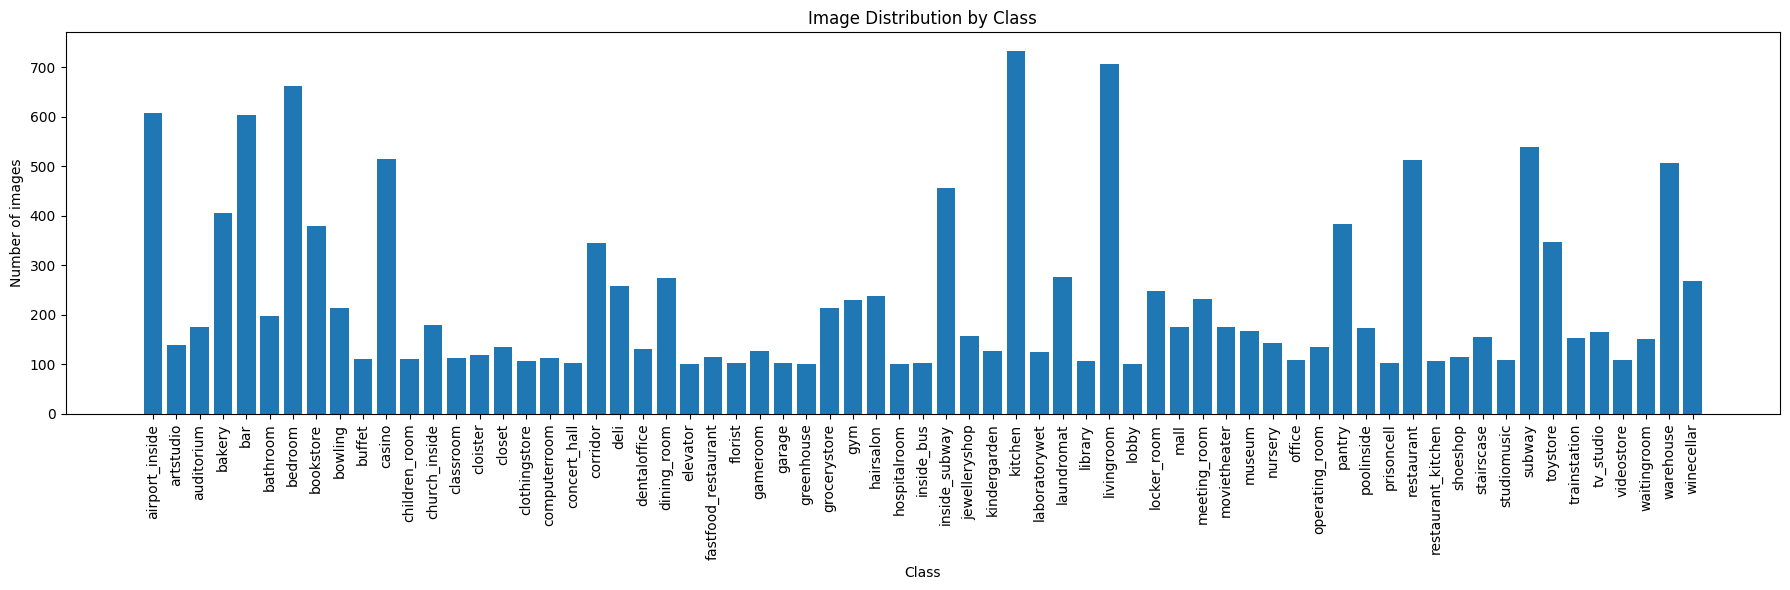

Done building splits
Train: created=10934, skipped=0
Val  : created=1562, skipped=0
Test : created=3124, skipped=0
ARTIFACT_ROOT: /kaggle/working/mit_indoor_split
Train size: 10934
Num classes: 67
Sample classes: ['airport_inside', 'artstudio', 'auditorium', 'bakery', 'bar', 'bathroom', 'bedroom', 'bookstore', 'bowling', 'buffet']


In [14]:
show_dataset_stats()
prepare_split_folders()

train_ds_check = ImageFolder(CFG.ARTIFACT_ROOT / "train")
print("Train size:", len(train_ds_check))
print("Num classes:", len(train_ds_check.classes))
print("Sample classes:", train_ds_check.classes[:10])

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = []

result_noaug = run_experiment(
    exp_name="vit_freeze_noaug",
    data_root=CFG.ARTIFACT_ROOT,
    device=device,
    batch_size=CFG.BATCH_SIZE,
    image_size=CFG.IMAGE_SIZE,
    num_epochs=20,
    use_oversampler=True,
    use_focal_loss=False,
    use_aug=False,
    freeze_backbone=True,
    optimizer_mode="freeze",
)
results.append(result_noaug)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 236MB/s]


Experiment      : vit_freeze_noaug
Use Aug         : False
Oversampler     : True
Focal Loss      : False
Freeze Backbone : True
Optimizer Mode  : freeze

Epoch 1/20


[vit_freeze_noaug] train_loss=1.6347 | train_acc=0.7445 | train_f1=0.7429 || val_loss=1.5243 | val_acc=0.7369 | val_f1=0.7200 || time=229.2s

Epoch 2/20


[vit_freeze_noaug] train_loss=1.1749 | train_acc=0.8843 | train_f1=0.8823 || val_loss=1.4556 | val_acc=0.7606 | val_f1=0.7500 || time=241.4s

Epoch 3/20


...

[vit_freeze_noaug] train_loss=0.8064 | train_acc=0.9971 | train_f1=0.9971 || val_loss=1.4324 | val_acc=0.7926 | val_f1=0.7747 || time=241.6s
EarlyStopping counter: 4/5

Epoch 17/20


[vit_freeze_noaug] train_loss=0.8037 | train_acc=0.9973 | train_f1=0.9972 || val_loss=1.4324 | val_acc=0.7990 | val_f1=0.7785 || time=241.7s

Epoch 18/20


[vit_freeze_noaug] train_loss=0.8009 | train_acc=0.9980 | train_f1=0.9980 || val_loss=1.4305 | val_acc=0.7990 | val_f1=0.7821 || time=241.6s
EarlyStopping counter: 1/5

Epoch 19/20


[vit_freeze_noaug] train_loss=0.8000 | train_acc=0.9975 | train_f1=0.9975 || val_loss=1.4320 | val_acc=0.8003 | val_f1=0.7844 || time=243.4s

Epoch 20/20


[vit_freeze_noaug] train_loss=0.7989 | train_acc=0.9983 | train_f1=0.9982 || val_loss=1.4313 | val_acc=0.7990 | val_f1=0.7833 || time=238.6s
EarlyStopping counter: 1/5
[vit_freeze_noaug] Loaded best model from: /kaggle/working/models/vit_freeze_noaug_best.pth


In [16]:
result_freeze_aug = run_experiment(
    exp_name="vit_freeze_aug",
    data_root=CFG.ARTIFACT_ROOT,
    device=device,
    batch_size=CFG.BATCH_SIZE,
    image_size=CFG.IMAGE_SIZE,
    num_epochs=20,
    use_oversampler=True,
    use_focal_loss=False,
    use_aug=True,
    freeze_backbone=True,
    optimizer_mode="freeze",
)
results.append(result_freeze_aug)

Experiment      : vit_freeze_aug
Use Aug         : True
Oversampler     : True
Focal Loss      : False
Freeze Backbone : True
Optimizer Mode  : freeze

Epoch 1/20


[vit_freeze_aug] train_loss=1.7498 | train_acc=0.7079 | train_f1=0.7024 || val_loss=1.5575 | val_acc=0.7362 | val_f1=0.7217 || time=299.5s

Epoch 2/20


[vit_freeze_aug] train_loss=1.2927 | train_acc=0.8439 | train_f1=0.8434 || val_loss=1.5113 | val_acc=0.7369 | val_f1=0.7311 || time=300.5s

Epoch 3/20


[vit_freeze_aug] train_loss=1.1819 | train_acc=0.8869 | train_f1=0.8857 || val_loss=1.5039 | val_acc=0.7599 | val_f1=0.7524 || time=297.9s

Epoch 4/20


[vit_freeze_aug] train_loss=1.1105 | train_acc=0.9087 | train_f1=0.9081 || val_loss=1.4421 | val_acc=0.7868 | val_f1=0.7757 || time=298.1s

Epoch 5/20


[vit_freeze_aug] train_loss=1.0542 | train_acc=0.9348 | train_f1=0.9343 || val_loss=1.4477 | val_acc=0.7759 | val_f1=0.7656 || time=302.7s
EarlyStopping counter: 1/5

Epoch 6/20


[vit_freeze_aug] train_loss=1.0198 | train_acc=0.9445 | train_f1=0.9439 || val_loss=1.4479 | val_acc=0.7772 | val_f1=0.7655 || time=296.9s
EarlyStopping counter: 2/5

Epoch 7/20


[vit_freeze_aug] train_loss=0.9993 | train_acc=0.9510 | train_f1=0.9515 || val_loss=1.4432 | val_acc=0.7791 | val_f1=0.7631 || time=299.0s
EarlyStopping counter: 3/5

Epoch 8/20


[vit_freeze_aug] train_loss=0.9744 | train_acc=0.9620 | train_f1=0.9616 || val_loss=1.4303 | val_acc=0.7862 | val_f1=0.7723 || time=299.1s
EarlyStopping counter: 4/5

Epoch 9/20


[vit_freeze_aug] train_loss=0.9606 | train_acc=0.9643 | train_f1=0.9645 || val_loss=1.4281 | val_acc=0.7836 | val_f1=0.7711 || time=299.1s
EarlyStopping counter: 5/5
[vit_freeze_aug] Early stopping triggered.
[vit_freeze_aug] Loaded best model from: /kaggle/working/models/vit_freeze_aug_best.pth


In [17]:
result_full = run_experiment(
    exp_name="vit_full_aug",
    data_root=CFG.ARTIFACT_ROOT,
    device=device,
    batch_size=CFG.BATCH_SIZE,
    image_size=CFG.IMAGE_SIZE,
    num_epochs=20,
    use_oversampler=True,
    use_focal_loss=False,
    use_aug=True,
    freeze_backbone=False,
    optimizer_mode="full",
)
results.append(result_full)

Experiment      : vit_full_aug
Use Aug         : True
Oversampler     : True
Focal Loss      : False
Freeze Backbone : False
Optimizer Mode  : full

Epoch 1/20


[vit_full_aug] train_loss=2.8363 | train_acc=0.5468 | train_f1=0.5418 || val_loss=1.9396 | val_acc=0.6863 | val_f1=0.6692 || time=541.3s

Epoch 2/20


[vit_full_aug] train_loss=1.4032 | train_acc=0.8264 | train_f1=0.8236 || val_loss=1.4917 | val_acc=0.7484 | val_f1=0.7350 || time=539.2s

Epoch 3/20


[vit_full_aug] train_loss=1.1026 | train_acc=0.8954 | train_f1=0.8924 || val_loss=1.4158 | val_acc=0.7772 | val_f1=0.7745 || time=541.1s

Epoch 4/20


[vit_full_aug] train_loss=0.9918 | train_acc=0.9291 | train_f1=0.9289 || val_loss=1.4046 | val_acc=0.7740 | val_f1=0.7657 || time=539.1s
EarlyStopping counter: 1/5

Epoch 5/20


...

[vit_full_aug] train_loss=0.7567 | train_acc=0.9980 | train_f1=0.9979 || val_loss=1.3620 | val_acc=0.8099 | val_f1=0.8039 || time=537.8s
EarlyStopping counter: 2/5

Epoch 17/20


[vit_full_aug] train_loss=0.7579 | train_acc=0.9972 | train_f1=0.9972 || val_loss=1.3478 | val_acc=0.8169 | val_f1=0.8120 || time=540.8s

Epoch 18/20


[vit_full_aug] train_loss=0.7556 | train_acc=0.9976 | train_f1=0.9976 || val_loss=1.3370 | val_acc=0.8163 | val_f1=0.8106 || time=539.2s
EarlyStopping counter: 1/5

Epoch 19/20


[vit_full_aug] train_loss=0.7553 | train_acc=0.9970 | train_f1=0.9970 || val_loss=1.3345 | val_acc=0.8169 | val_f1=0.8161 || time=538.8s
EarlyStopping counter: 2/5

Epoch 20/20


[vit_full_aug] train_loss=0.7522 | train_acc=0.9986 | train_f1=0.9987 || val_loss=1.3391 | val_acc=0.8175 | val_f1=0.8160 || time=538.4s
[vit_full_aug] Loaded best model from: /kaggle/working/models/vit_full_aug_best.pth


In [18]:
result_layerwise_aug = run_experiment(
    exp_name="vit_layerwise_aug",
    data_root=CFG.ARTIFACT_ROOT,
    device=device,
    batch_size=CFG.BATCH_SIZE,
    image_size=CFG.IMAGE_SIZE,
    num_epochs=20,
    use_oversampler=True,
    use_focal_loss=False,
    use_aug=True,
    freeze_backbone=False,
    optimizer_mode="layerwise",
)
results.append(result_layerwise_aug)

Experiment      : vit_layerwise_aug
Use Aug         : True
Oversampler     : True
Focal Loss      : False
Freeze Backbone : False
Optimizer Mode  : layerwise

Epoch 1/20


[vit_layerwise_aug] train_loss=1.7660 | train_acc=0.6984 | train_f1=0.6979 || val_loss=1.5167 | val_acc=0.7350 | val_f1=0.7255 || time=539.2s

Epoch 2/20


[vit_layerwise_aug] train_loss=1.1217 | train_acc=0.8805 | train_f1=0.8788 || val_loss=1.4166 | val_acc=0.7625 | val_f1=0.7617 || time=540.6s

Epoch 3/20


[vit_layerwise_aug] train_loss=0.9869 | train_acc=0.9216 | train_f1=0.9214 || val_loss=1.4259 | val_acc=0.7676 | val_f1=0.7608 || time=540.1s

Epoch 4/20


[vit_layerwise_aug] train_loss=0.9202 | train_acc=0.9472 | train_f1=0.9473 || val_loss=1.4524 | val_acc=0.7606 | val_f1=0.7504 || time=539.8s
EarlyStopping counter: 1/5

Epoch 5/20


...

[vit_layerwise_aug] train_loss=0.7494 | train_acc=0.9973 | train_f1=0.9973 || val_loss=1.4023 | val_acc=0.8086 | val_f1=0.8033 || time=540.4s
EarlyStopping counter: 3/5

Epoch 17/20


[vit_layerwise_aug] train_loss=0.7481 | train_acc=0.9978 | train_f1=0.9978 || val_loss=1.3854 | val_acc=0.8105 | val_f1=0.8011 || time=541.8s
EarlyStopping counter: 4/5

Epoch 18/20


[vit_layerwise_aug] train_loss=0.7472 | train_acc=0.9978 | train_f1=0.9978 || val_loss=1.3743 | val_acc=0.8201 | val_f1=0.8110 || time=539.0s

Epoch 19/20


[vit_layerwise_aug] train_loss=0.7444 | train_acc=0.9984 | train_f1=0.9985 || val_loss=1.3672 | val_acc=0.8239 | val_f1=0.8164 || time=539.6s

Epoch 20/20


[vit_layerwise_aug] train_loss=0.7446 | train_acc=0.9984 | train_f1=0.9984 || val_loss=1.3653 | val_acc=0.8227 | val_f1=0.8159 || time=539.6s
EarlyStopping counter: 1/5
[vit_layerwise_aug] Loaded best model from: /kaggle/working/models/vit_layerwise_aug_best.pth


In [19]:
for r in results:
    print(
        f"{r['exp_name']:<20} | "
        f"Test Acc: {r['test_acc']:.4f} | "
        f"Test F1: {r['test_f1']:.4f}"
    )

df_results = pd.DataFrame([
    {
        "Experiment": r["exp_name"],
        "Augmentation": r["use_aug"],
        "Freeze Backbone": r["freeze_backbone"],
        "Optimizer Mode": r["optimizer_mode"],
        "Test Loss": r["test_loss"],
        "Test Accuracy": r["test_acc"],
        "Test Macro F1": r["test_f1"],
        "Best Val Accuracy": max(r["history"]["val_acc"]),
        "Best Val F1": max(r["history"]["val_f1"]),
    }
    for r in results
]).sort_values(by="Test Accuracy", ascending=False).reset_index(drop=True)

display(df_results)

vit_freeze_noaug     | Test Acc: 0.7990 | Test F1: 0.7797
vit_freeze_aug       | Test Acc: 0.7762 | Test F1: 0.7649
vit_full_aug         | Test Acc: 0.8307 | Test F1: 0.8196
vit_layerwise_aug    | Test Acc: 0.8204 | Test F1: 0.8155


,Experiment,Augmentation,Freeze Backbone,Optimizer Mode,Test Loss,Test Accuracy,Test Macro F1,Best Val Accuracy,Best Val F1
0,vit_full_aug,True,False,full,1.298701,0.830666,0.819561,0.817542,0.816077
1,vit_layerwise_aug,True,False,layerwise,1.342489,0.820423,0.815531,0.823944,0.816441
2,vit_freeze_noaug,False,True,freeze,1.424145,0.798976,0.779678,0.800256,0.784362
3,vit_freeze_aug,True,True,freeze,1.448404,0.776248,0.764937,0.786812,0.775691


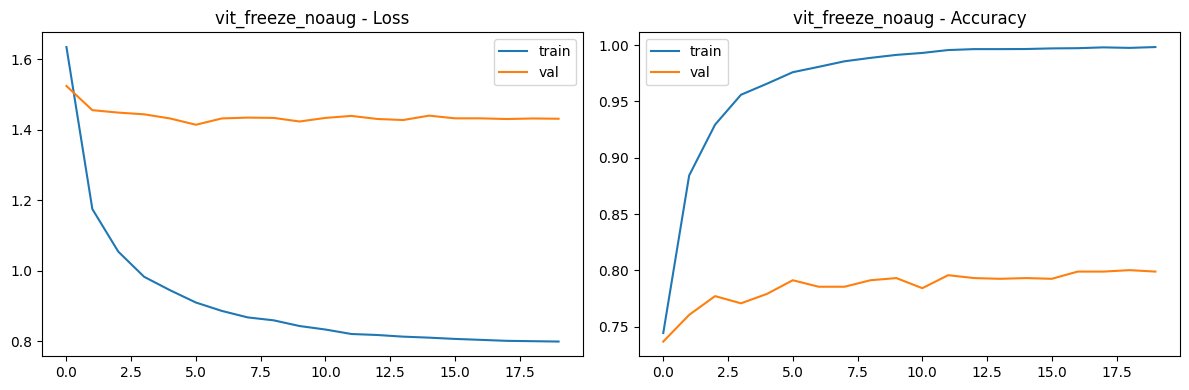

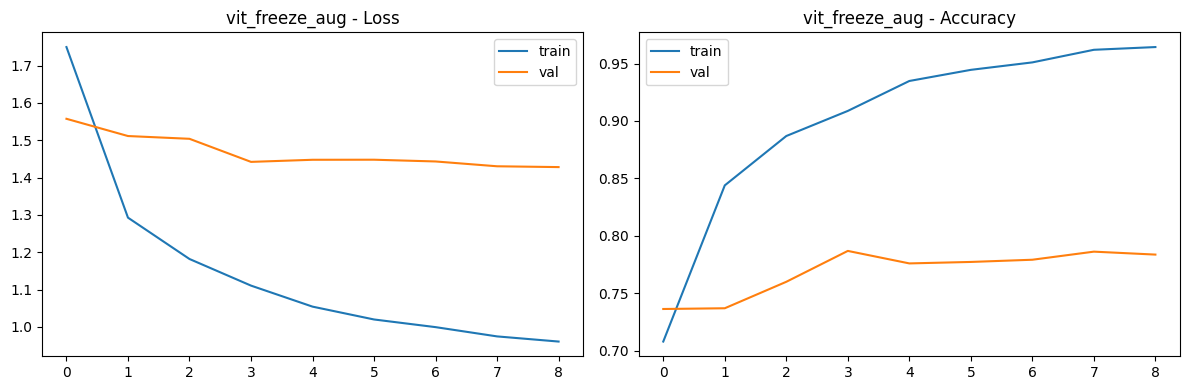

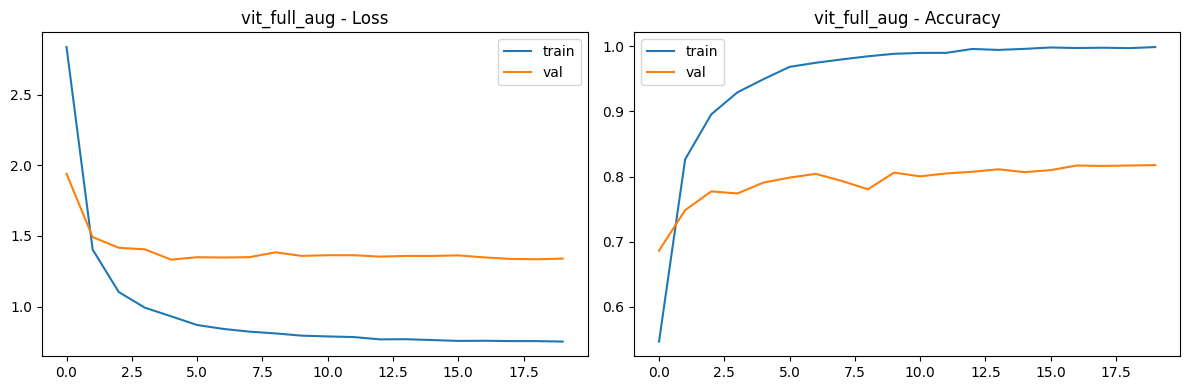

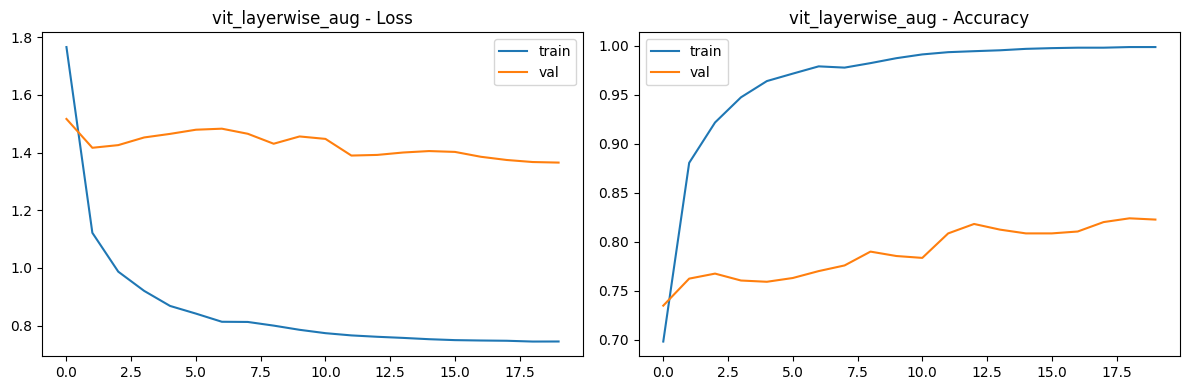

In [20]:
for r in results:
    plot_history(r["history"], r["exp_name"])


===== vit_freeze_noaug =====
                     precision    recall  f1-score   support

     airport_inside     0.7288    0.7107    0.7197       121
          artstudio     0.7037    0.6786    0.6909        28
         auditorium     0.6667    0.6286    0.6471        35
             bakery     0.8333    0.8642    0.8485        81
                bar     0.6739    0.7686    0.7181       121
           bathroom     0.8537    0.8974    0.8750        39
            bedroom     0.8014    0.8496    0.8248       133
          bookstore     0.7229    0.7895    0.7547        76
            bowling     0.8889    0.9302    0.9091        43
             buffet     0.8500    0.7727    0.8095        22
             casino     0.9412    0.9320    0.9366       103
      children_room     0.8235    0.6087    0.7000        23
      church_inside     0.8684    0.9167    0.8919        36
          classroom     0.7308    0.8261    0.7755        23
           cloister     0.7931    0.9583    0.8679    

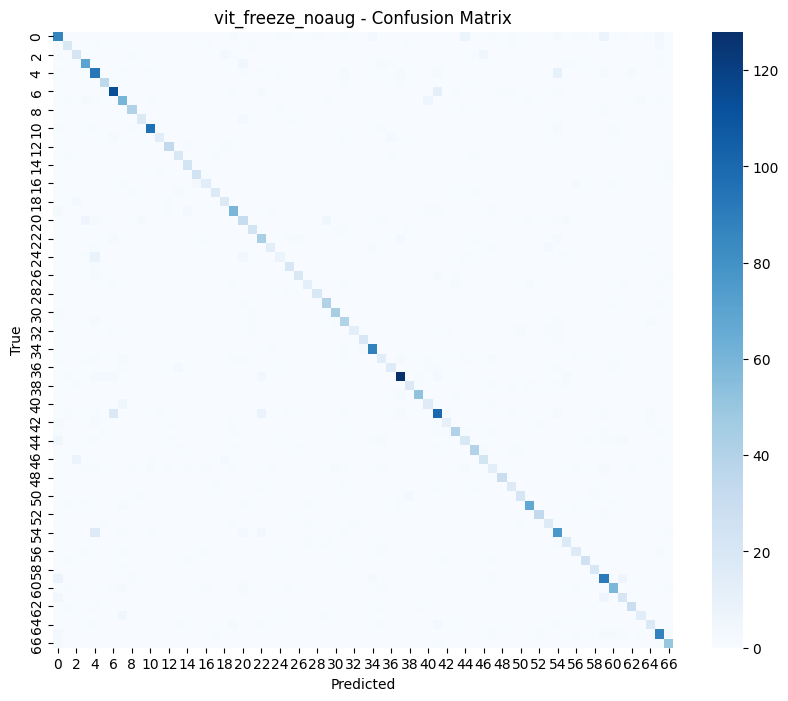


===== vit_freeze_aug =====
                     precision    recall  f1-score   support

     airport_inside     0.8065    0.6198    0.7009       121
          artstudio     0.8261    0.6786    0.7451        28
         auditorium     0.6316    0.6857    0.6575        35
             bakery     0.8171    0.8272    0.8221        81
                bar     0.7387    0.6777    0.7069       121
           bathroom     0.8333    0.8974    0.8642        39
            bedroom     0.8319    0.7444    0.7857       133
          bookstore     0.6882    0.8421    0.7574        76
            bowling     0.8000    0.9302    0.8602        43
             buffet     0.9000    0.8182    0.8571        22
             casino     0.9579    0.8835    0.9192       103
      children_room     0.5862    0.7391    0.6538        23
      church_inside     0.8649    0.8889    0.8767        36
          classroom     0.4762    0.8696    0.6154        23
           cloister     0.8462    0.9167    0.8800      

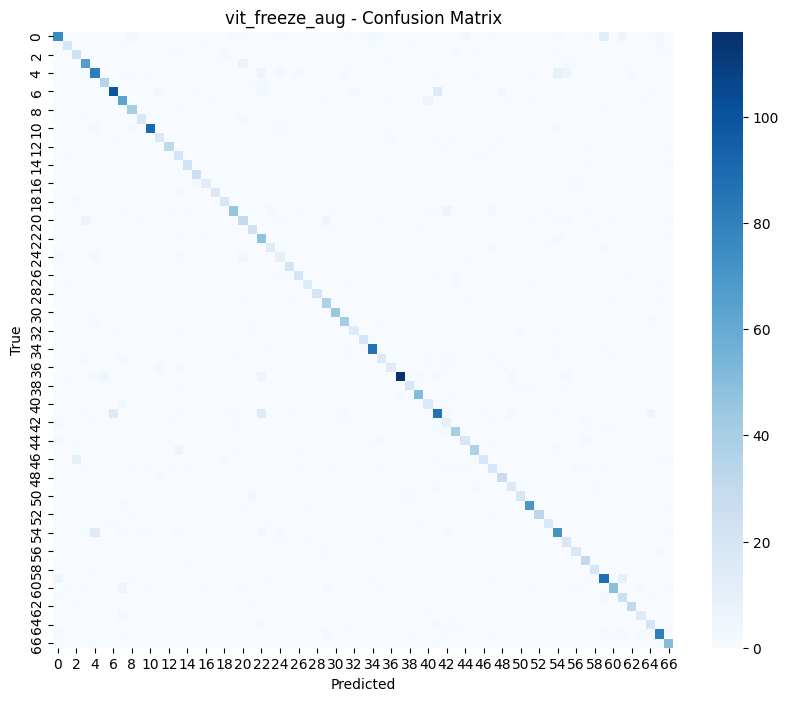


===== vit_full_aug =====
                     precision    recall  f1-score   support

     airport_inside     0.7143    0.7851    0.7480       121
          artstudio     0.8077    0.7500    0.7778        28
         auditorium     0.6585    0.7714    0.7105        35
             bakery     0.8554    0.8765    0.8659        81
                bar     0.7348    0.8017    0.7668       121
           bathroom     0.7674    0.8462    0.8049        39
            bedroom     0.8769    0.8571    0.8669       133
          bookstore     0.7746    0.7237    0.7483        76
            bowling     0.8571    0.9767    0.9130        43
             buffet     0.8947    0.7727    0.8293        22
             casino     0.9899    0.9515    0.9703       103
      children_room     0.8235    0.6087    0.7000        23
      church_inside     0.8947    0.9444    0.9189        36
          classroom     0.8077    0.9130    0.8571        23
           cloister     0.7667    0.9583    0.8519        

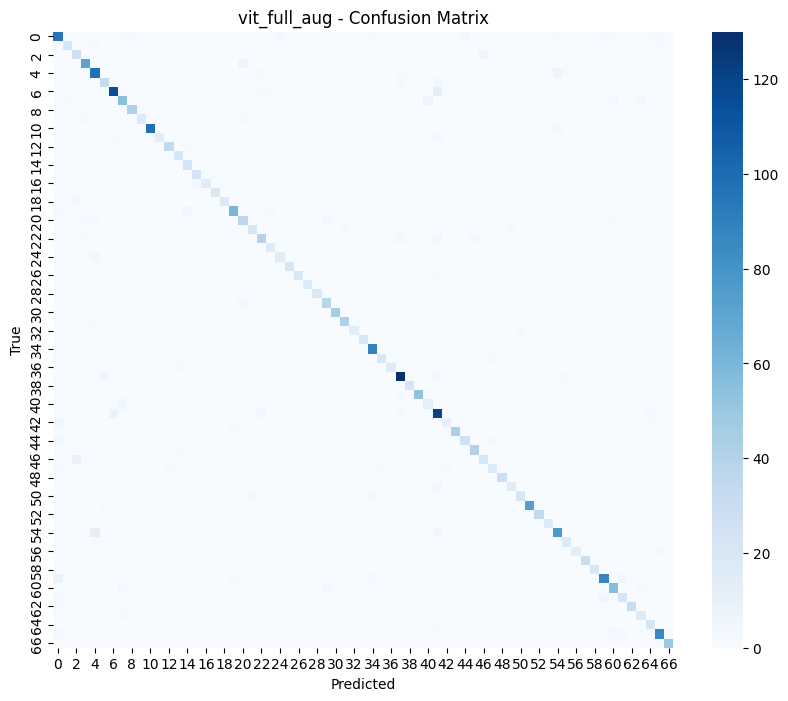


===== vit_layerwise_aug =====
                     precision    recall  f1-score   support

     airport_inside     0.6992    0.7686    0.7323       121
          artstudio     0.8000    0.7143    0.7547        28
         auditorium     0.6047    0.7429    0.6667        35
             bakery     0.8500    0.8395    0.8447        81
                bar     0.6815    0.7603    0.7188       121
           bathroom     0.8000    0.8205    0.8101        39
            bedroom     0.8406    0.8722    0.8561       133
          bookstore     0.7590    0.8289    0.7925        76
            bowling     0.9524    0.9302    0.9412        43
             buffet     0.8636    0.8636    0.8636        22
             casino     0.9802    0.9612    0.9706       103
      children_room     0.6800    0.7391    0.7083        23
      church_inside     0.8333    0.9722    0.8974        36
          classroom     0.8077    0.9130    0.8571        23
           cloister     0.8846    0.9583    0.9200   

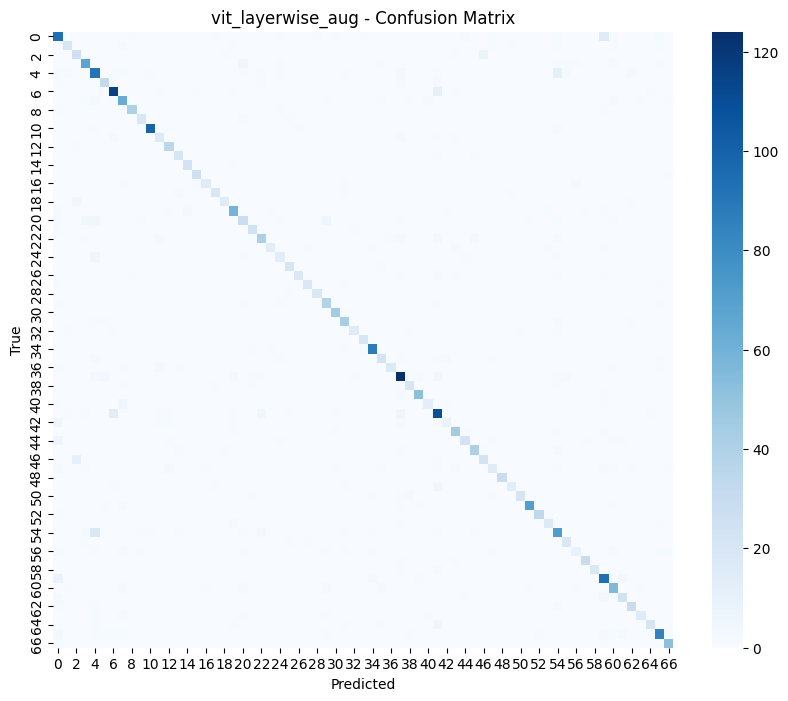

In [21]:
for r in results:
    analyze_results(
        r["y_true"],
        r["y_pred"],
        r["classes"],
        r["exp_name"]
    )

True : shoeshop
Pred : toystore
Conf : 0.554


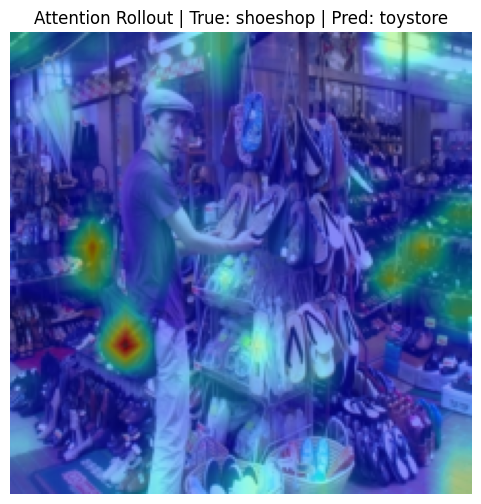

In [22]:
result = results[-1]

vis_model = ViTClassifier(
    num_classes=len(result["classes"]),
    freeze_backbone=False,
    dropout=CFG.DROPOUT
).to(device)

vis_model.load_state_dict(torch.load(result["model_path"], map_location=device))
vis_model = patch_torchvision_vit_attention(vis_model)
vis_model.eval()

test_loader_vis = DataLoader(
    result["test_ds"],
    batch_size=1,
    shuffle=True,
    num_workers=0
)

img, label = next(iter(test_loader_vis))
img = img.to(device)

pred_idx, pred_name, conf = predict_one(vis_model, img, result["classes"])
true_name = result["classes"][label.item()]

print("True :", true_name)
print("Pred :", pred_name)
print("Conf :", round(conf, 4))

rollout = get_attention_rollout(vis_model, img, start_layer=0)

show_attention_map(
    img[0],
    rollout,
    title=f"Attention Rollout | True: {true_name} | Pred: {pred_name}"
)

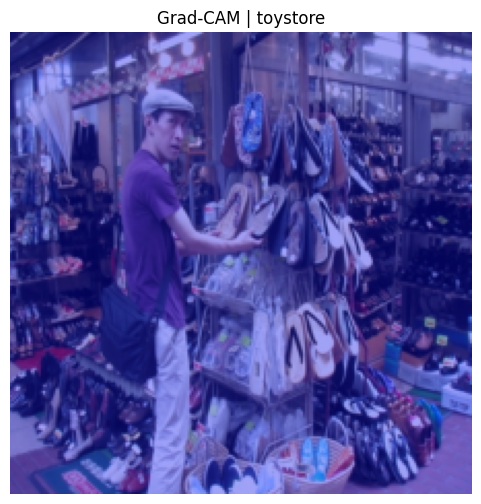

In [23]:
show_gradcam_vit(
    model=vis_model,
    image_tensor=img,
    target_category=pred_idx,
    class_name=pred_name
)